<a href="https://colab.research.google.com/github/tasneemsk500/Algthms_Machine_Learning_Practice/blob/main/Khan_Tasneem_Shahnewaz_A3_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CAP 4611 &mdash; Assignment 3: Classification (Telco Customer Churn)
Make sure your file name is `yourlastname_firstname.ipynb`

`This jupyter notebook is prepared by "Tasneem Shahnewaz Khan".`


> Fill in all code cells and markdown discussion cells as instructed.

<font color='red'>Don't forget to submit the phase 1 pdf and then finally the google colab link with edit permissions enabled </font>

## A. Load Data and Perform Basic EDA [10 pts = 1 + 1 + 1 + 2 + 5]

### I. **Import libraries:** pandas, numpy, matplotlib (set `%matplotlib inline`), matplotlib's pyplot, seaborn, missingno, scipy's stats, sklearn. (1 pt)

In [ ]:
# Write your code here
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import scipy.stats as st
from sklearn import ensemble, tree, linear_model
import missingno as msno

### II. Load the dataset and display the number of rows and columns. (1 pt)

In [ ]:
# Write your code here
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/A3 classification/telco_churn2.csv")
print(df.shape) #print the shape

(7043, 24)


### III. Display the first 5 and last 5 rows. (1 pt)

In [ ]:
# Write your code here
print(df.head(5)) #the top 5 rows

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... StreamingMovies  \
0  No phone service             DSL             No  ...              No   
1                No             DSL            Yes  ...              No   
2                No             DSL            Yes  ...              No   
3  No phone service             DSL            Yes  ...              No   
4                No     Fiber optic             No  ...              No   

         Contract PaperlessBilling              PaymentMethod Monthl

In [ ]:
print(df.tail(5)) #the bottom 5 rows

      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
7038          Yes               Yes             DSL            Yes  ...   
7039          Yes               Yes     Fiber optic             No  ...   
7040           No  No phone service             DSL            Yes  ...   
7041          Yes               Yes     Fiber optic             No  ...   
7042          Yes                No     Fiber optic            Yes  ...   

     StreamingMovies        Contract PaperlessBilling  \
7038             Yes        One year              Yes   
7039          

### IV. Show how many columns contain null values. (2 pts)

In [ ]:
# Write your code here
nulls = df.isnull().sum().to_frame('nulls') #sum up nulls and make a df
# print(nulls)
nulls.sort_values("nulls", inplace = True, ascending = False) #sort it by descending order

for index, row in nulls.iterrows(): #print it in well formatted way
 print(index, row['nulls'])

Education 5679
customerID 0
SeniorCitizen 0
gender 0
Dependents 0
tenure 0
PhoneService 0
Partner 0
MultipleLines 0
InternetService 0
OnlineBackup 0
OnlineSecurity 0
TechSupport 0
StreamingTV 0
StreamingMovies 0
DeviceProtection 0
Contract 0
PaperlessBilling 0
MonthlyCharges 0
PaymentMethod 0
TotalCharges 0
SupportTicketID 0
ActiveCountryCode 0
Churn 0


### V. Plot the target (`Churn`) distribution. In a markdown cell, discuss the class imbalance, what issues it may cause in your models, and propose at least one solution. (5 pts)

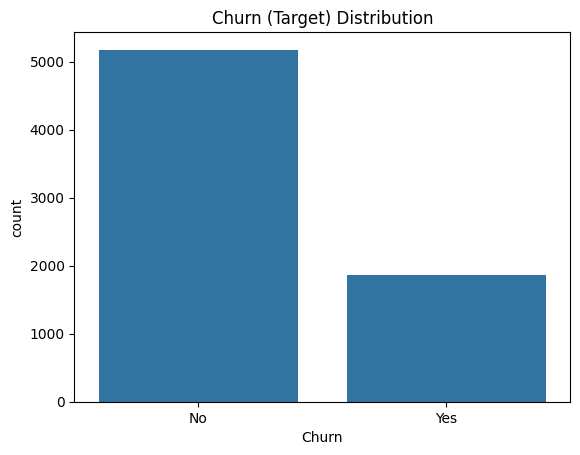

In [ ]:
# Write your code here
#Here Churn is a categorical data
# suitable plot distribution = bar plot / stacked bar plot
sns.countplot(data = df, x = 'Churn')
plt.title("Churn (Target) Distribution")
plt.show()

*Write your answer here.*

Suppose we're tracking the baggage data set of an airport that has 99% correctly handled bags and 1% delyed bags. If we built an ML model to predict whether a bag will be delayed or correctly handled, the model will show 99% accuracy. This 99% accuracy is misleading. The data set is imbalanced and should be balanced before training to prevent misleading results.

One solution to class imbalance is undersampling. We group the dataset by one or more variables; from each group, randomly sample (without replacement) N instances, where N is the number of instances in the smallest group.

## B. Feature Selection and Pre-processing [32 pts]

### I. Drop identifier and constant columns (4 pts)
Look at the number of unique values in `customerID`, `SupportTicketID`, and `ActiveCountryCode`. Two of them are essentially unique per row and one is constant for every row. In a markdown cell, explain why each one carries no predictive value, then drop all three. Show sample rows to verify.

In [ ]:
# Write your code here
#number of unique vallues:
print(df[['customerID', 'SupportTicketID', 'ActiveCountryCode']].nunique())

customerID           7043
SupportTicketID      7042
ActiveCountryCode       1
dtype: int64


**Why each one carries no predictive value:**

CustomerID got high cardinality, close to the number of instances we have. It's just a nominial variable to identify the customer.

SupportTicketID is similar to customerID data with high cardinality and is mainly used to identify the customer. It's a nominial value that is not helpful for predicting the target.

The ActiveCountryCode in this case is a nominal value used to identify the country codes. This needs to be treated as a categorical feature and does not contribute to predicting the value.

In [ ]:
#remove them then print a sample to verify that they're gone
df_clean = df.drop(columns = ['customerID', 'SupportTicketID', 'ActiveCountryCode'])
print(df_clean.head())

   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   
3    Male              0      No         No      45           No   
4  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  ...  \
0  No phone service             DSL             No          Yes  ...   
1                No             DSL            Yes           No  ...   
2                No             DSL            Yes          Yes  ...   
3  No phone service             DSL            Yes           No  ...   
4                No     Fiber optic             No           No  ...   

  TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling  \
0          No          No              No  Month-to-month              Yes   
1 

### II. Clean the TotalCharges column (4 pts)
`TotalCharges` is stored as text because a few rows are blank. Show that it is stored as text and how many blanks exist, convert it to numeric, then handle the resulting missing values (these rows correspond to brand new customers). Confirm the column is now numeric.

In [ ]:
# Write your code here
#display the data type to show it's not stored as numeric value
print("Data type is of: ", df_clean['TotalCharges'].dtype)
print("\n")

#number of blanks that exist
blanks = df_clean['TotalCharges'].str.strip() == ''
print("TotalCharges blank value count:", blanks.sum())
print("\n")

#convert it to numeric
df_clean['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

#handle the resulting missing values
df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(0)

#confirm it's numeric value now
print("Data type is now of: ", df_clean['TotalCharges'].dtype)

Data type is of:  object


TotalCharges blank value count: 11


Data type is now of:  float64


### III. Education level (4 pts = 1 + 2 + 1)

#### 1. Show the unique values of `Education`. (1 pt)

In [ ]:
# Write your code here
print(df['Education'].unique())

[nan 'Associate Degree' 'High School Graduate' "Bachelor's Degree"
 "Master's Degree"]


#### 2. Convert `Education` to ordinal values (High School Graduate → 0, Associate Degree → 1, Bachelor’s Degree → 2, Master’s Degree → 3). This column has many missing values, so decide how to handle them and, in a markdown cell, justify your choice. (2 pts)

In [ ]:
# Write your code here
#make a dict for education
education_dist = {'High School Graduate' : 0, 'Associate Degree' : 1, "Bachelor's Degree" : 2, "Master's Degree" : 3}
#map the education
df_clean['Education'] = df_clean['Education'].map(education_dist)


*Write your answer here.*

From Section A, we decided to use median since we cannot alter the distribution of the dataset by adding something else. We use median to keep the data useful for us and median is unaffected by any skewness of the data.

#### 3. Show sample rows to verify the change. (1 pt)

In [ ]:
# Write your code here
df_clean['Education'] = df_clean['Education'].fillna(df_clean['Education'].median())
print(df_clean.head())

   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   
3    Male              0      No         No      45           No   
4  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  ...  \
0  No phone service             DSL             No          Yes  ...   
1                No             DSL            Yes           No  ...   
2                No             DSL            Yes          Yes  ...   
3  No phone service             DSL            Yes           No  ...   
4                No     Fiber optic             No           No  ...   

  TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling  \
0          No          No              No  Month-to-month              Yes   
1 

### IV. Contract column (4 pts = 1 + 2 + 1)

#### 1. Show the unique values of `Contract`. (1 pt)

In [ ]:
# Write your code here
print(df_clean['Contract'].unique())

['Month-to-month' 'One year' 'Two year']


#### 2. Convert `Contract` to ordinal values based on contract length (Month-to-month → 0, One year → 1, Two year → 2). (2 pts)

In [ ]:
# Write your code here
#dict fist to map it
contract_dist = {'Month-to-month' : 0, 'One year' : 1, 'Two year' : 2}
#map the contract
df_clean['Contract'] = df_clean['Contract'].map(contract_dist)

#### 3. Show the updated unique values. (1 pt)

In [ ]:
# Write your code here
print(df_clean['Contract'].unique())

[0 1 2]


### V. Other columns (8 pts = 2 + 4 + 1 + 1)

#### 1. Show the unique values of the remaining nominal columns: `gender`, `Partner`, `Dependents`, `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`, `PaperlessBilling`, `PaymentMethod`. Storing them in a list and looping is an easy approach. (2 pts)

In [ ]:
# Write your code here
#store them in a list
nominal_col = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'PaymentMethod']

#loop them
for col in nominal_col:
  print(col + ': ' + df_clean[col].unique())

['gender: Female' 'gender: Male']
['Partner: Yes' 'Partner: No']
['Dependents: No' 'Dependents: Yes']
['PhoneService: No' 'PhoneService: Yes']
['MultipleLines: No phone service' 'MultipleLines: No'
 'MultipleLines: Yes']
['InternetService: DSL' 'InternetService: Fiber optic'
 'InternetService: No']
['OnlineSecurity: No' 'OnlineSecurity: Yes'
 'OnlineSecurity: No internet service']
['OnlineBackup: Yes' 'OnlineBackup: No'
 'OnlineBackup: No internet service']
['DeviceProtection: No' 'DeviceProtection: Yes'
 'DeviceProtection: No internet service']
['TechSupport: No' 'TechSupport: Yes' 'TechSupport: No internet service']
['StreamingTV: No' 'StreamingTV: Yes' 'StreamingTV: No internet service']
['StreamingMovies: No' 'StreamingMovies: Yes'
 'StreamingMovies: No internet service']
['PaperlessBilling: Yes' 'PaperlessBilling: No']
['PaymentMethod: Electronic check' 'PaymentMethod: Mailed check'
 'PaymentMethod: Bank transfer (automatic)'
 'PaymentMethod: Credit card (automatic)']


#### 2. Use pandas’ `get_dummies` to create binary columns for those nominal columns. (4 pts)

In [ ]:
# Write your code here
df_clean_categorical = df_clean.copy() #for future use in section G onwards
df_clean_dummies = pd.get_dummies(df_clean, columns=nominal_col)

#### 3. In a markdown cell, write a short paragraph on the difference between `get_dummies` and `OneHotEncoder`. (1 pt)

*Write your answer here.*

1. dummies is similar to OneHotEncoder except it's not actually a helpful encoder for future data
2. dummies can transform the data but it cannot properly encode the future data. OneHotEncoding can be used for future instances.
3. If we applied dummies on the existing data, we cannot apply it again on the new incoming data that OneHotEncoding can.
4. one-hot-encoding learns from previous categories and enforces the exact same schema onto the future dataset. For instance, if our previous dataset has 3 classes, like dog, cat and monkey, one-hot-encoder remembers that format. if a new incoming data has dog and cat only,get_dummies will crash but one-hot-concoder won't. Thus, get_dummies crashes if there's a data mismatch.

#### 4. Show the first 5 and last 5 rows, and show the shape of the table. (1 pt)

In [ ]:
# Write your code here
print(df_clean_dummies.head())
print(df_clean_dummies.tail())
print(df_clean_dummies.shape)

   SeniorCitizen  tenure  Contract  MonthlyCharges  TotalCharges  Education  \
0              0       1         0           29.85         29.85        1.0   
1              0      34         1           56.95       1889.50        1.0   
2              0       2         0           53.85        108.15        1.0   
3              0      45         1           42.30       1840.75        1.0   
4              0       2         0           70.70        151.65        0.0   

  Churn  gender_Female  gender_Male  Partner_No  ...  StreamingTV_Yes  \
0    No           True        False       False  ...            False   
1    No          False         True        True  ...            False   
2   Yes          False         True        True  ...            False   
3    No          False         True        True  ...            False   
4   Yes           True        False        True  ...            False   

   StreamingMovies_No  StreamingMovies_No internet service  \
0                True   

### VI. Encode the target (2 pts)
Convert `Churn` to 1 and 0. Confirm there are no leftover identifier or duplicate raw columns (the columns replaced by `get_dummies` should no longer appear in raw form).

In [ ]:
# Write your code here
#make a dict for churn Yes = 1, No = 0
churn_dict = {"Yes": 1, "No": 0}
#map it to the churn column
df_clean_dummies['Churn'] = df_clean_dummies['Churn'].map(churn_dict)

#confirm there's no leftovers
print(df_clean_dummies['Churn'].unique())

[0 1]


In [ ]:
#confirm the rest of the columns
print(df_clean_dummies.select_dtypes(include='object').columns.tolist())
print("\n")
print(df_clean_dummies.head())

[]


   SeniorCitizen  tenure  Contract  MonthlyCharges  TotalCharges  Education  \
0              0       1         0           29.85         29.85        1.0   
1              0      34         1           56.95       1889.50        1.0   
2              0       2         0           53.85        108.15        1.0   
3              0      45         1           42.30       1840.75        1.0   
4              0       2         0           70.70        151.65        0.0   

   Churn  gender_Female  gender_Male  Partner_No  ...  StreamingTV_Yes  \
0      0           True        False       False  ...            False   
1      0          False         True        True  ...            False   
2      1          False         True        True  ...            False   
3      0          False         True        True  ...            False   
4      1           True        False        True  ...            False   

   StreamingMovies_No  StreamingMovies_No internet service  \
0            

### VII. Feature scaling (5 pts = 2.5 + 2.5)

#### 1. Use `sklearn.preprocessing.MinMaxScaler` to scale all columns. (2.5 pts)

In [ ]:
# Write your code here
#import the library
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled = scaler.fit_transform(df_clean_dummies)
df_scaled = pd.DataFrame(scaled, columns=df_clean_dummies.columns)

#### 2. Show some scaled records. (2.5 pts)

In [ ]:
# Write your code here
print(df_scaled.head())

   SeniorCitizen    tenure  Contract  MonthlyCharges  TotalCharges  Education  \
0            0.0  0.013889       0.0        0.115423      0.003437   0.333333   
1            0.0  0.472222       0.5        0.385075      0.217564   0.333333   
2            0.0  0.027778       0.0        0.354229      0.012453   0.333333   
3            0.0  0.625000       0.5        0.239303      0.211951   0.333333   
4            0.0  0.027778       0.0        0.521891      0.017462   0.000000   

   Churn  gender_Female  gender_Male  Partner_No  ...  StreamingTV_Yes  \
0    0.0            1.0          0.0         0.0  ...              0.0   
1    0.0            0.0          1.0         1.0  ...              0.0   
2    1.0            0.0          1.0         1.0  ...              0.0   
3    0.0            0.0          1.0         1.0  ...              0.0   
4    1.0            1.0          0.0         1.0  ...              0.0   

   StreamingMovies_No  StreamingMovies_No internet service  \
0     

### VIII. Move the target (1 pt)
Move the `Churn` column to the last position of the DataFrame and show that it has changed.

In [ ]:
# Write your code here
churn_col = df_scaled.pop('Churn')
df_scaled['Churn'] = churn_col
print(df_scaled.columns.tolist())

['SeniorCitizen', 'tenure', 'Contract', 'MonthlyCharges', 'TotalCharges', 'Education', 'gender_Female', 'gender_Male', 'Partner_No', 'Partner_Yes', 'Dependents_No', 'Dependents_Yes', 'PhoneService_No', 'PhoneService_Yes', 'MultipleLines_No', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'PaperlessBilling_No', 'PaperlessBilling_Yes', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic

## C. X/Y and Training/Test Split with Stratified Sampling and SMOTE [15 pts = 2 + 1.5 + 4 + 1.5 + 4 + 2]

### I. Copy all features into X and the target into Y. (2 pts)

In [ ]:
# Write your code here
#separate the target using drop functon
X = df_scaled.drop('Churn', axis=1)
Y = df_scaled['Churn']

### II. Show the ratio of 1 and 0 in Y. (1.5 pts)

In [ ]:
# Write your code here
#in 100% percentage
print(Y.value_counts(normalize=True) * 100)

Churn
0.0    73.463013
1.0    26.536987
Name: proportion, dtype: float64


### III. Use sklearn’s `train_test_split` to split the data into training and test sets. The test set should contain 30% of the instances and you must use `random_state = 0`. Use the `stratify` parameter so the class ratio is preserved in both sets. (4 pts)

In [ ]:
# Write your code here
#take from library
from sklearn.model_selection import train_test_split

#split into respective variables
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size= 0.3, random_state = 0, stratify = Y)

### IV. Show the ratio of 1 and 0 in y_train and then y_test. (1.5 pts)

In [ ]:
# Write your code here
#ratio of y_train
print(y_train.value_counts(normalize=True) * 100)
#ratio of y_test
print(y_test.value_counts(normalize=True) * 100)

Churn
0.0    73.46856
1.0    26.53144
Name: proportion, dtype: float64
Churn
0.0    73.450071
1.0    26.549929
Name: proportion, dtype: float64


### V. Use imblearn’s SMOTE to balance X_train. Keep a copy of the unbalanced training set; you will need it in later sections. (Helpful link: https://imbalanced-learn.org/stable/over_sampling.html, section 2.1.2) (4 pts)

In [ ]:
# Write your code here
#make a copy
X_train_copy = X_train.copy()
y_train_copy = y_train.copy()

#import from library
from imblearn.over_sampling import SMOTE, ADASYN

#fit them
X_train, y_train = SMOTE().fit_resample(X_train, y_train)

### VI. Show the ratio of 0 and 1 in the rebalanced training set. Consider, do you now have 50% of each class? (2 pts)

In [ ]:
# Write your code here
print(y_train.value_counts(normalize=True) * 100)

Churn
1.0    50.0
0.0    50.0
Name: proportion, dtype: float64


Yes, now i have 50% of each class under the Churn target

## D. PCA and Logistic Regression [20 pts = 7 + 4 + 2 + 2 + 2 + 3]

### I. Build a pipeline to determine how many PCA components give the best logistic regression model, using the balanced training set. The number of components should range up to the maximum number of features you have. Produce a plot and in a markdown cell decide how many components to keep. (7 pts)
You can follow this link: https://machinelearningmastery.com/principal-components-analysis-for-dimensionality-reduction-in-python/ (consider using the code right before the plot).

>1 0.704 (0.016)
>2 0.728 (0.013)
>3 0.751 (0.013)
>4 0.752 (0.014)
>5 0.754 (0.013)
>6 0.757 (0.015)
>7 0.757 (0.015)
>8 0.757 (0.014)
>9 0.759 (0.015)
>10 0.759 (0.015)
>11 0.760 (0.015)
>12 0.760 (0.015)
>13 0.759 (0.015)
>14 0.759 (0.015)
>15 0.759 (0.014)
>16 0.757 (0.015)
>17 0.759 (0.014)
>18 0.758 (0.014)
>19 0.775 (0.013)
>20 0.778 (0.012)
>21 0.778 (0.012)
>22 0.780 (0.011)
>23 0.780 (0.011)
>24 0.780 (0.011)
>25 0.780 (0.011)
>26 0.780 (0.011)
>27 0.780 (0.011)
>28 0.780 (0.011)
>29 0.780 (0.011)
>30 0.780 (0.011)
>31 0.780 (0.011)
>32 0.780 (0.011)
>33 0.780 (0.011)
>34 0.780 (0.011)
>35 0.780 (0.011)
>36 0.780 (0.011)
>37 0.780 (0.011)
>38 0.780 (0.011)
>39 0.780 (0.011)
>40 0.780 (0.011)
>41 0.780 (0.011)
>42 0.780 (0.011)
>43 0.780 (0.011)
>44 0.780 (0.011)


/tmp/ipykernel_833/258794718.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(results, labels=names, showmeans=True)


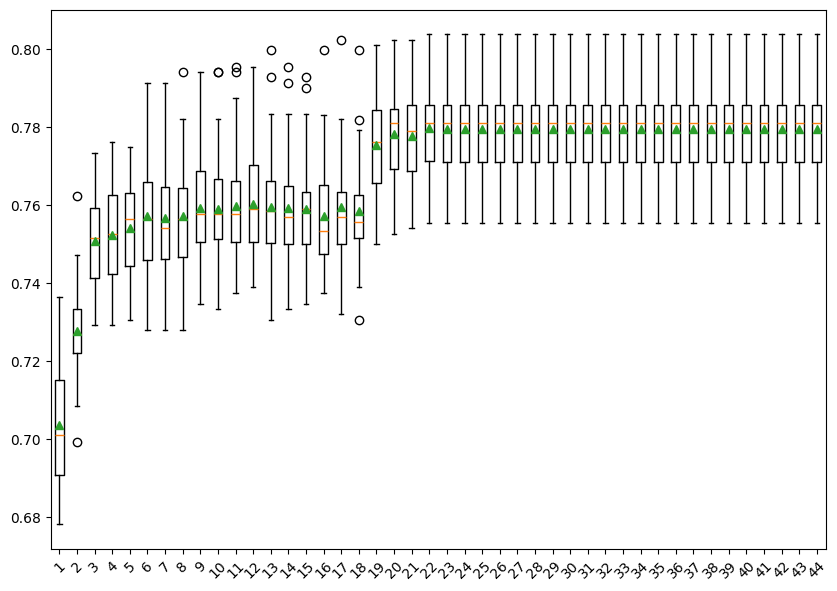

In [ ]:
# Write your code here
#first import the libraries
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

# get a list of models to evaluate
def get_models(max_features):
	models = dict()
	for i in range(1, max_features + 1):
		steps = [('pca', PCA(n_components=i)), ('m', LogisticRegression())]
		models[str(i)] = Pipeline(steps=steps)
	return models

# evaluate a given model using cross-validation
def evaluate_model(model, X, y):
	cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
	scores = cross_val_score(model, X, y, scoring='accuracy', cv=cv, n_jobs=-1, error_score='raise')
	return scores

## get the models to evaluate
models = get_models(X_train.shape[1]) #.shape[1] = number of columns. no of columns = num of features we have in this dataset

# evaluate the models and store results
results, names = list(), list()

for name, model in models.items():
	scores = evaluate_model(model, X_train, y_train)
	results.append(scores)
	names.append(name)
	print('>%s %.3f (%.3f)' % (name, np.mean(scores), np.std(scores)))

# plot model performance for comparison
plt.figure(figsize=(10,7))
plt.boxplot(results, labels=names, showmeans=True)
plt.xticks(rotation=45)
plt.show()


*Write your answer here.*

from the above box plot, we can see the trend of increasing classification accuracy with the number of components with a limit at 22.

### II. Based on the chosen number of components, evaluate accuracy on the test set using `accuracy_score`. (4 pts)

In [ ]:
# Write your code here
#import
from sklearn.metrics import accuracy_score

n_components = 22 #my chosen limit from the plot

# define the pipeline
steps = [('pca', PCA(n_components=n_components)), ('m', LogisticRegression())]
model = Pipeline(steps=steps)

# fit the model on the whole dataset
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy: ", accuracy_score(y_test, y_pred) * 100)

Accuracy:  75.43776620918126


### III. Show the confusion matrix, and in a markdown cell, interpret the numbers you see. (2 pts)

In [ ]:
# Write your code here
#import library
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[1149  403]
 [ 116  445]]


*Write your answer here.*

We know from B, VI, the order of class is 0 and 1.

We set for churn; <br>
Yes = 1 (positive or they will churn) <br>
No = 0 (negative or they won't churn)

|  | predicted 0 | predicted 1 |
| --- | --- | --- |
| actual 0 | 1149 | 403 |
| actual 1 | 116 | 445 |

Thus, we can interpret the following:
1. 1149 is TN (true negatives)
2. 403 is FP (false positive)
3. 116 is FN (false negative)
4. 445 is TP (true positive)


### IV. Show precision, recall, and F1 score on the test set. (2 pts)

In [ ]:
# Write your code
#import again
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

Precision: 0.5247641509433962
Recall: 0.7932263814616756
F1: 0.631653655074521


### V. Plot the ROC curve and find the AUC. (2 pts)

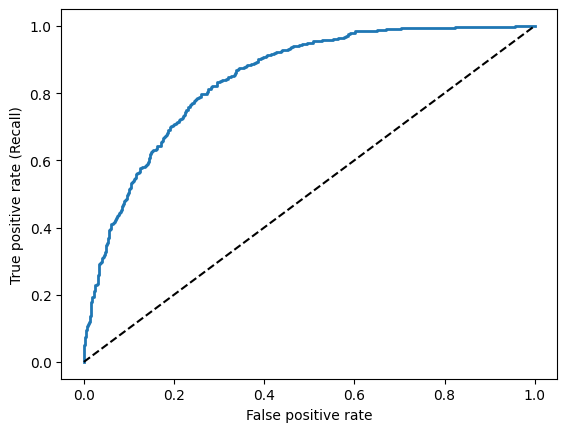

In [ ]:
# Write your code here
#do the roc
from sklearn.metrics import roc_curve

#get the probability score on the test set
y_probas = model.predict_proba(X_test)
y_scores = y_probas[:, 1]

#fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)
fpr, tpr, thresholds = roc_curve(y_test, y_scores) #do it on the test set

#plot the curve
def plot_roc_curve(fpr, tpr, label=None):
 plt.plot(fpr, tpr, linewidth=2, label=label)
 plt.plot([0, 1], [0, 1], 'k--') # dashed diagonal

plot_roc_curve(fpr, tpr)

plt.xlabel("False positive rate")
plt.ylabel("True positive rate (Recall)")
plt.show()

In [ ]:
#for auc
from sklearn.metrics import roc_auc_score #for auc

#print
print(roc_auc_score(y_test, y_scores))

0.8449909954609773


### VI. Plot the precision–recall curve for different thresholds. In a markdown cell, discuss the plot. (3 pts)

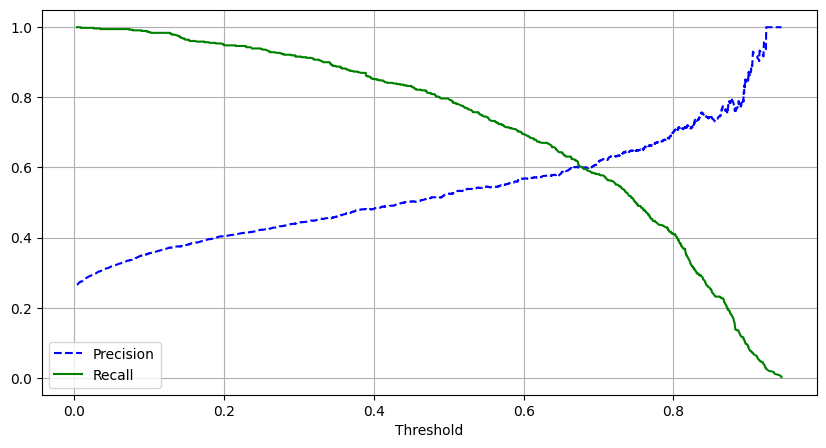

In [ ]:
# Write your code here
from sklearn.metrics import precision_recall_curve
#precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)
precisions, recalls, prc_thresholds = precision_recall_curve(y_test, y_scores)

#plot here
def plot_precision_recall_vs_threshold(precisions, recalls, prc_thresholds):
 plt.plot(prc_thresholds, precisions[:-1], "b--", label="Precision")
 plt.plot(prc_thresholds, recalls[:-1], "g-", label="Recall")
 #[...] # highlight the threshold, add the legend, axis label and grid
 plt.xlabel("Threshold")
 plt.legend()
 plt.grid(True)

plt.figure(figsize=(10,5))
plot_precision_recall_vs_threshold(precisions, recalls, prc_thresholds)
plt.show()
#dotted line precision, solid line recall


*Write your answer here.*

from the above plot, we observe that increasing the threshold, decreases recall but increases the precision. With increasing precision, we can see that precision becomes bumpier.

## E. Softmax Regression [3 pts = 2 + 1]

### I. Short answer (markdown): How is softmax regression related to logistic regression? Discuss two different libraries that can build a softmax regression model. (2 pts)

*Write your answer here.*

Softmax regression is the multi-class version of logistic regression. In other worda, applying logistic regression in the context of multi-class problem.

1. One library we can use is using LogisticRegression library from sklearn.linear_model and set multi_class to multinomial as seen below:

softmax_reg = LogisticRegression (multi_class = "multinomial",  solver="lbfgs", C=10)

2. Another library is using SoftmaxRegression directly from mlxtend.classifier.

### II. Short answer (markdown): If we have 4 classes and 10 features, how many weights plus biases are part of the softmax model? Show your calculation. (1 pt)

*Write your answer here.*

We know weights = (m+1) * k, where m is the number of features and k is the number of classes

weights (including bias ) = (10 + 1 ) * 4 <br>
= 11 * 4 <br>
= 44

## F. KNN [25 pts = 4 + 4 + 3 + 2 + 4 + 4 + 4]

*Always use the rebalanced training set for training unless a section says otherwise.*

### I. Train a KNN classifier (k = 10) on the **unbalanced** training set, test it, and show the confusion matrix and classification report. (4 pts)

In [ ]:
# Write your code here
#import the library
from sklearn.neighbors import KNeighborsClassifier

#set k = 10
classifier = KNeighborsClassifier(n_neighbors=10)
classifier.fit(X_train_copy, y_train_copy)

#new predict value based off unbalanced sets
y_pred_knn_unbalanced = classifier.predict(X_test)

#printt
print(confusion_matrix(y_test, y_pred_knn_unbalanced))

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_knn_unbalanced))

[[1370  182]
 [ 323  238]]
              precision    recall  f1-score   support

         0.0       0.81      0.88      0.84      1552
         1.0       0.57      0.42      0.49       561

    accuracy                           0.76      2113
   macro avg       0.69      0.65      0.66      2113
weighted avg       0.74      0.76      0.75      2113



### II. Train a KNN classifier (k = 10) on the **rebalanced** training set, test it, and show the confusion matrix and classification report. (4 pts)

In [ ]:
# Write your code here
#set k = 10
classifier = KNeighborsClassifier(n_neighbors=10)
classifier.fit(X_train, y_train)

#new predict value based off balanced sets
y_pred_knn_balanced = classifier.predict(X_test)

#printt
print(confusion_matrix(y_test, y_pred_knn_balanced))
print(classification_report(y_test, y_pred_knn_balanced))

[[1095  457]
 [ 153  408]]
              precision    recall  f1-score   support

         0.0       0.88      0.71      0.78      1552
         1.0       0.47      0.73      0.57       561

    accuracy                           0.71      2113
   macro avg       0.67      0.72      0.68      2113
weighted avg       0.77      0.71      0.73      2113



### III. Use grid search to tune the following hyper paramerters: number of neighbors (1 to 20), weights (uniform or distance), and metric (Euclidean, Manhattan, or Minkowski). While creating an instance of GridSearchCV, use multiple evaluation metrics such as AUC and accuracy based on the example available at Link to sklearn. Also, some helpful links and codes: https://github.com/oguzhankir/Hyperparameter_Tuning/tree/main/Knn_tuning  and https://www.youtube.com/watch?v=TvB_3jVIHhg  (3 pts) //note that grid search process can take a couple of minutes.

In [ ]:
# Write your code here
#import the library
from sklearn.model_selection import GridSearchCV

#create search space
search_space = {
    'n_neighbors': list(range(1, 21)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

grid_search = GridSearchCV(estimator=KNeighborsClassifier(), param_grid = search_space, scoring =['accuracy', 'roc_auc'], refit = 'roc_auc', cv=5, verbose=4)

#train
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 120 candidates, totalling 600 fits
[CV 1/5] END metric=euclidean, n_neighbors=1, weights=uniform; accuracy: (test=0.813) roc_auc: (test=0.813) total time=   0.2s
[CV 2/5] END metric=euclidean, n_neighbors=1, weights=uniform; accuracy: (test=0.806) roc_auc: (test=0.806) total time=   0.2s
[CV 3/5] END metric=euclidean, n_neighbors=1, weights=uniform; accuracy: (test=0.839) roc_auc: (test=0.839) total time=   0.2s
[CV 4/5] END metric=euclidean, n_neighbors=1, weights=uniform; accuracy: (test=0.859) roc_auc: (test=0.859) total time=   0.2s
[CV 5/5] END metric=euclidean, n_neighbors=1, weights=uniform; accuracy: (test=0.851) roc_auc: (test=0.851) total time=   0.2s
[CV 1/5] END metric=euclidean, n_neighbors=1, weights=distance; accuracy: (test=0.813) roc_auc: (test=0.813) total time=   0.2s
[CV 2/5] END metric=euclidean, n_neighbors=1, weights=distance; accuracy: (test=0.806) roc_auc: (test=0.806) total time=   0.1s
[CV 3/5] END metric=euclidean, n_neighbors=1, 

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean', 'manhattan', 'minkowski'],
                         'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                         13, 14, 15, 16, 17, 18, 19, 20],
                         'weights': ['uniform', 'distance']},
             refit='roc_auc', scoring=['accuracy', 'roc_auc'], verbose=4)

### IV. Print the best parameters. (2 pts)

In [ ]:
# Write your code here
print(grid_search.best_params_)

{'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'distance'}


### V. Train a model with the best parameters, test it, and print the confusion matrix, classification report, and the ROC AUC. (4 pts)

In [ ]:
# Write your code here
#train the model with the best parameter from the above grid search
best_estimators = grid_search.best_estimator_
y_pred_knn_best_parameter = best_estimators.predict(X_test)

#get the probability
#get the probability score on the test set
y_proba_best_parameter = best_estimators.predict_proba(X_test)
y_scores_best_parameter = y_proba_best_parameter[:, 1]

#display the matrix, report and roc and auc
print(confusion_matrix(y_test, y_pred_knn_best_parameter))
print(classification_report(y_test, y_pred_knn_best_parameter))
print("ROC AUC:", roc_auc_score(y_test, y_scores_best_parameter))

[[1179  373]
 [ 235  326]]
              precision    recall  f1-score   support

         0.0       0.83      0.76      0.80      1552
         1.0       0.47      0.58      0.52       561

    accuracy                           0.71      2113
   macro avg       0.65      0.67      0.66      2113
weighted avg       0.74      0.71      0.72      2113

ROC AUC: 0.7470620394362055


### VI. Apply PCA with the best KNN setup, test it, and print the confusion matrix, classification report, and the ROC AUC. (4 pts)

In [ ]:
# Write your code here
#import tthe library
from sklearn.decomposition import PCA

#use the same component number used before
pca = PCA(n_components=22)

#transform
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

#train
classifier_pca = KNeighborsClassifier(**grid_search.best_params_) #n_neighbours needs int not object so unpack with **
classifier_pca.fit(X_train_pca, y_train)

#predict
y_pred_pca = classifier_pca.predict(X_test_pca)
y_proba_pca = classifier_pca.predict_proba(X_test_pca)
y_scores_pca = y_proba_pca[:, 1]

#display the results

print(confusion_matrix(y_test, y_pred_pca))
print(classification_report(y_test, y_pred_pca))
print("ROC AUC:", roc_auc_score(y_test, y_scores_pca))

[[1123  429]
 [ 231  330]]
              precision    recall  f1-score   support

         0.0       0.83      0.72      0.77      1552
         1.0       0.43      0.59      0.50       561

    accuracy                           0.69      2113
   macro avg       0.63      0.66      0.64      2113
weighted avg       0.72      0.69      0.70      2113

ROC AUC: 0.7389941332671774


### VII. Short answer (markdown): Write a short discussion of the four KNN models above and their differences. (4 pts)

*Write your answer here.*

For the first model, we set the knn to 10 and computed the report based on imbalances datsets. As majority of the classes leans towards "No" for the Churn class we get a low precision of 0.81, high recall of 0.88, and an accuracy of 0.76. It resulted predicting some loyal customers false positives.

For the second model, we set the knn to 10 and computed the report based on balanced datsets. Here, the precision improved with 0.88 but recall fell to 0.71 score, with accuracy drooped to 0.71. The model accurately predicts more customers who are actullay going to churn and less false alerts.

For the third model, we set the knn to 10 and computed the report based on balanced datsets with grid search. This lowered the precision to 0.83 but raised the recall to 0.76. The hyperparameter tuning ooptimised the ROC AUC to 0.75 than the accuracy of 0.71

For the fourth model, we set the knn to 10 and computed the report based on balanced datsets with PCA. Using PCA, we reduced the dimentionality by choosing the n_component 22 and retaining the precision and recall score similar to third model with precision 0.83, recall 0.72, roc auc of 0.74 and accuracy 0.69.

## G. Naive Bayes [15 pts = 7.5 + 7.5]

### I. Train a GaussianNB model, test it, and print the confusion matrix and classification report. Plot the ROC curve, show the AUC, and count the misclassifications. (7.5 pts)

In [ ]:
# Write your code here
#import the libraries
from sklearn.naive_bayes import GaussianNB

#data already loaded, train-test splitted

#initiallise gaussianNB
model_gNB = GaussianNB()

#traib the modek
model_gNB.fit(X_train, y_train)

#predict on test set
y_pred_gNB = model_gNB.predict(X_test)
y_proba_gNB = model_gNB.predict_proba(X_test)
y_scores_gNB = y_proba_gNB[:, 1]

In [ ]:
#display the results
print(confusion_matrix(y_test, y_pred_gNB))
print(classification_report(y_test, y_pred_gNB))

[[1024  528]
 [  85  476]]
              precision    recall  f1-score   support

         0.0       0.92      0.66      0.77      1552
         1.0       0.47      0.85      0.61       561

    accuracy                           0.71      2113
   macro avg       0.70      0.75      0.69      2113
weighted avg       0.80      0.71      0.73      2113



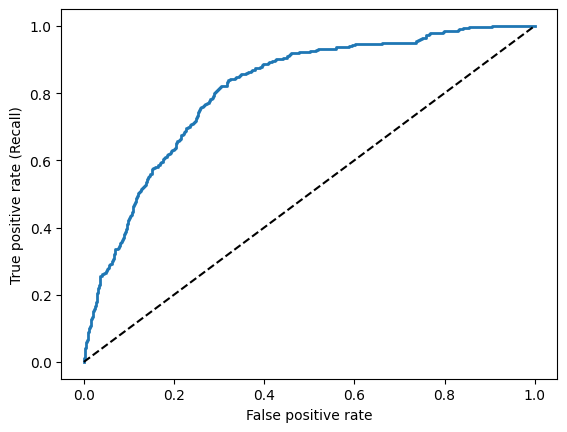

In [ ]:
#fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)
fpr, tpr, thresholds = roc_curve(y_test, y_scores_gNB) #do it on the test set

#plot the curve

plot_roc_curve(fpr, tpr)

plt.xlabel("False positive rate")
plt.ylabel("True positive rate (Recall)")
plt.show()

In [ ]:
print("ROC AUC:", roc_auc_score(y_test, y_scores_gNB))

ROC AUC: 0.812689508793208


In [ ]:
#misclassification
missclassified = (y_test != y_pred_gNB).sum()
print("Misclassifications: ", missclassified)

Misclassifications:  613


### II. Train a CategoricalNB model, test it, and print the confusion matrix and classification report. Plot the ROC curve, show the AUC, and count the misclassifications. Note: CategoricalNB expects integer-encoded categorical features. (7.5 pts)

In [ ]:
# Write your code here
#import the library
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder  # Encoders for X and y
from sklearn.naive_bayes import CategoricalNB
from imblearn.over_sampling import SMOTEN #to keep the consistency of using balanced data

#create the categorical column
#store them in a list
#nominal_col = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'PaymentMethod']
categorical_col = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'PaymentMethod', 'Contract']

#Encode features (X)
X_categorical = df_clean_categorical[categorical_col]
X_encoder = OrdinalEncoder()          # Converts categories → numbers
X_encoded = X_encoder.fit_transform(X_categorical)

# Step 4: Encode target (y)
y = df_clean['Churn']
y_encoder = LabelEncoder()            # Converts labels → numbers //works for 1D array. You could use oridinalEncoder, but in that case you had to covert this to 2D array first
y_encoded = y_encoder.fit_transform(y)

# Step 5: Train-test split
X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(X_encoded, y_encoded, test_size=0.3, random_state=0, stratify = y_encoded)  # 70% train, 30% test

X_train_cat, y_train_cat = SMOTEN().fit_resample(X_train_cat, y_train_cat)

# Step 6: Train model
model_cNB = CategoricalNB()               # Initialize model
model_cNB.fit(X_train_cat, y_train_cat)

# Step 7: Predict
y_pred_cNB = model_cNB.predict(X_test_cat)        # Predict labels for test set

# Step 8: Evaluate
# accuracy = accuracy_score(y_test_cat, y_pred_cNB)  # Compare predictions with actual
# print("Accuracy:", accuracy)

#predict on test set
y_proba_cNB = model_cNB.predict_proba(X_test_cat)
y_scores_cNB = y_proba_cNB[:, 1]

In [ ]:
#display the results
print(confusion_matrix(y_test_cat, y_pred_cNB))
print(classification_report(y_test_cat, y_pred_cNB))

[[989 563]
 [ 79 482]]
              precision    recall  f1-score   support

           0       0.93      0.64      0.75      1552
           1       0.46      0.86      0.60       561

    accuracy                           0.70      2113
   macro avg       0.69      0.75      0.68      2113
weighted avg       0.80      0.70      0.71      2113



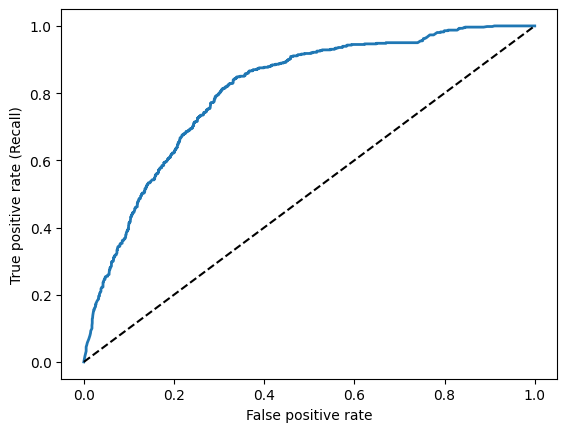

In [ ]:
#fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)
fpr, tpr, thresholds = roc_curve(y_test_cat, y_scores_cNB) #do it on the test set

#plot the curve

plot_roc_curve(fpr, tpr)

plt.xlabel("False positive rate")
plt.ylabel("True positive rate (Recall)")
plt.show()

In [ ]:
print("\nROC AUC:", roc_auc_score(y_test_cat, y_scores_cNB))


ROC AUC: 0.8067837256739622


In [ ]:
#misclassification
missclassified_cNB = (y_test_cat != y_pred_cNB).sum()
print("Misclassifications: ", missclassified_cNB)

Misclassifications:  642


## H. Support Vector Machine [20 pts = 10 + 10]

### I. Build an SVC model. Use grid search to tune some parameters and show the best parameters found. (10 pts)

In [ ]:
# Write your code here
#import from webcourse svm example
from sklearn.svm import SVC
# model_svc = SVC(kernel = 'sigmoid') #just to show you an examle of passing a kernel of your choice
# model_svc.fit(X_train,y_train)

#gridsearch part
param_grid = {'C': [0.1,1, 10, 50], 'gamma': [1,0.1,0.01,0.001], 'kernel': ['rbf', 'sigmoid']} # dropped poly, too slow. create list of paraeters you would like to tune. We have already gone thorugh these parameters in our lecture and note

grid_svc = GridSearchCV(SVC(probability=True),param_grid,refit=True,verbose=3)

grid_svc.fit(X_train,y_train)  #it may take time. We have used verbose = 3 to see some output while it is being processed

Fitting 5 folds for each of 32 candidates, totalling 160 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.679 total time=  15.3s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.703 total time=  15.3s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.743 total time=  16.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.792 total time=  16.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.790 total time=  15.2s
[CV 1/5] END ....C=0.1, gamma=1, kernel=sigmoid;, score=0.483 total time=  21.5s
[CV 2/5] END ....C=0.1, gamma=1, kernel=sigmoid;, score=0.471 total time=  22.8s
[CV 3/5] END ....C=0.1, gamma=1, kernel=sigmoid;, score=0.468 total time=  21.9s
[CV 4/5] END ....C=0.1, gamma=1, kernel=sigmoid;, score=0.452 total time=  22.2s
[CV 5/5] END ....C=0.1, gamma=1, kernel=sigmoid;, score=0.464 total time=  22.3s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.761 total time=   9.2s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf

GridSearchCV(estimator=SVC(probability=True),
             param_grid={'C': [0.1, 1, 10, 50], 'gamma': [1, 0.1, 0.01, 0.001],
                         'kernel': ['rbf', 'sigmoid']},
             verbose=3)

In [ ]:
print(grid_svc.best_params_)

{'C': 50, 'gamma': 1, 'kernel': 'rbf'}


In [ ]:
print(grid_svc.best_estimator_)

SVC(C=50, gamma=1, probability=True)


### II. Test the model and print the confusion matrix and classification report. Plot the ROC curve, show the AUC, and count the misclassifications. (10 pts)

In [ ]:
# Write your code here
# Step 7: Predict
# y_pred_svc = model_svc.predict(X_test)        # Predict labels for test set
# #predict on test set
# y_proba_svc = model_svc.predict_proba(X_test)
# y_scores_svc = y_proba_svc[:, 1]
y_pred_svc = grid_svc.predict(X_test)
#get the probability
#get the probability score on the test set
y_proba_svc = grid_svc.predict_proba(X_test)
y_scores_svc = y_proba_svc[:, 1]

In [ ]:
#display the results
print(confusion_matrix(y_test, y_pred_svc))
print(classification_report(y_test, y_pred_svc))

[[1371  181]
 [ 332  229]]
              precision    recall  f1-score   support

         0.0       0.81      0.88      0.84      1552
         1.0       0.56      0.41      0.47       561

    accuracy                           0.76      2113
   macro avg       0.68      0.65      0.66      2113
weighted avg       0.74      0.76      0.74      2113



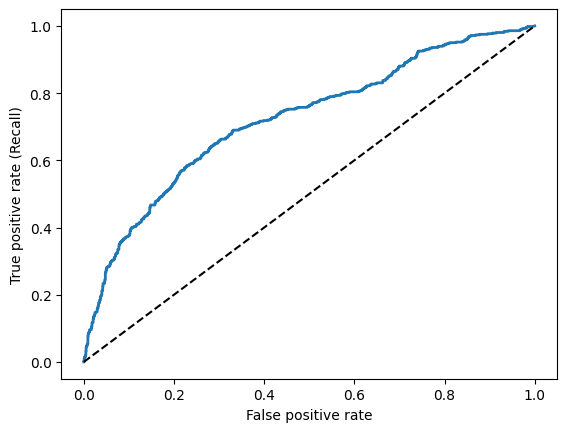

In [ ]:
#fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)
fpr, tpr, thresholds = roc_curve(y_test, y_scores_svc) #do it on the test set

#plot the curve

plot_roc_curve(fpr, tpr)

plt.xlabel("False positive rate")
plt.ylabel("True positive rate (Recall)")
plt.show()

In [ ]:
print("\nROC AUC:", roc_auc_score(y_test, y_scores_svc))


ROC AUC: 0.7215914833599795


In [ ]:
#misclassification
missclassified_svc = (y_test != y_pred_svc).sum()
print("Misclassifications: ", missclassified_svc)

Misclassifications:  513


## I. Decision Tree [25 pts = 11 + 10 + 4]

### I. Build a decision tree using `DecisionTreeClassifier` on the **unbalanced** training set with entropy as the criterion. Try different `max_depth` values or use grid search. Test it, print the confusion matrix and classification report, plot the ROC curve, show the AUC, count the misclassifications, and show the decision tree (you can simply import tree from sklearn and call tree.plot_tree with your model and the call plt.show. At the beginning of this process, use plt.figure to change the figsize). (11 pts)

In [ ]:
# Write your code here
#import the kibraries as mentioned above
from sklearn.tree import DecisionTreeClassifier
import sklearn.tree as tree

param_grid = {'max_depth': list(range(2, 15))} #testing out different values in max_depth

#initialise
grid_decisionTree_unbalanced = GridSearchCV(DecisionTreeClassifier(criterion='entropy'),param_grid, scoring='roc_auc')

#train on the prev unbalanaced dataset
grid_decisionTree_unbalanced.fit(X_train_copy, y_train_copy)

GridSearchCV(estimator=DecisionTreeClassifier(criterion='entropy'),
             param_grid={'max_depth': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,
                                       14]},
             scoring='roc_auc')

In [ ]:
#save the best estimator
best_estimator_tree = grid_decisionTree_unbalanced.best_estimator_

#test it
y_pred_decisionTree_unbalanced = best_estimator_tree.predict(X_test)
y_proba_decisionTree_unbalanced = best_estimator_tree.predict_proba(X_test)
y_score_decisionTree_unbalanced = y_proba_decisionTree_unbalanced[:, 1]

In [ ]:
#display the results
print(confusion_matrix(y_test, y_pred_decisionTree_unbalanced))
print(classification_report(y_test, y_pred_decisionTree_unbalanced))

[[1390  162]
 [ 273  288]]
              precision    recall  f1-score   support

         0.0       0.84      0.90      0.86      1552
         1.0       0.64      0.51      0.57       561

    accuracy                           0.79      2113
   macro avg       0.74      0.70      0.72      2113
weighted avg       0.78      0.79      0.79      2113



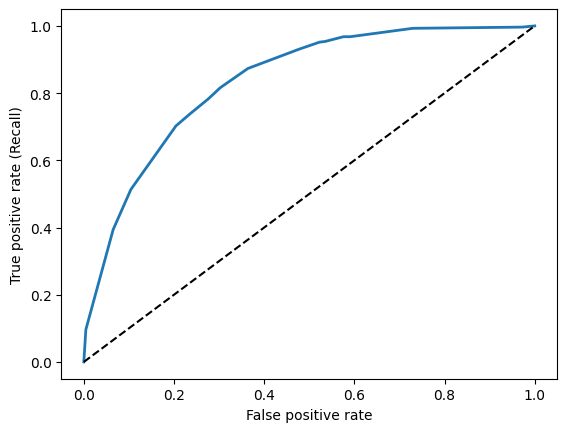

In [ ]:
#fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)
fpr, tpr, thresholds = roc_curve(y_test, y_score_decisionTree_unbalanced) #do it on the test set

#plot the curve

plot_roc_curve(fpr, tpr)

plt.xlabel("False positive rate")
plt.ylabel("True positive rate (Recall)")
plt.show()

In [ ]:
print("ROC AUC:", roc_auc_score(y_test, y_score_decisionTree_unbalanced))

ROC AUC: 0.835552309021078


In [ ]:
#misclassification
missclassified_decisionTree = (y_test != y_pred_decisionTree_unbalanced).sum()
print("Misclassifications: ", missclassified_decisionTree)

Misclassifications:  435


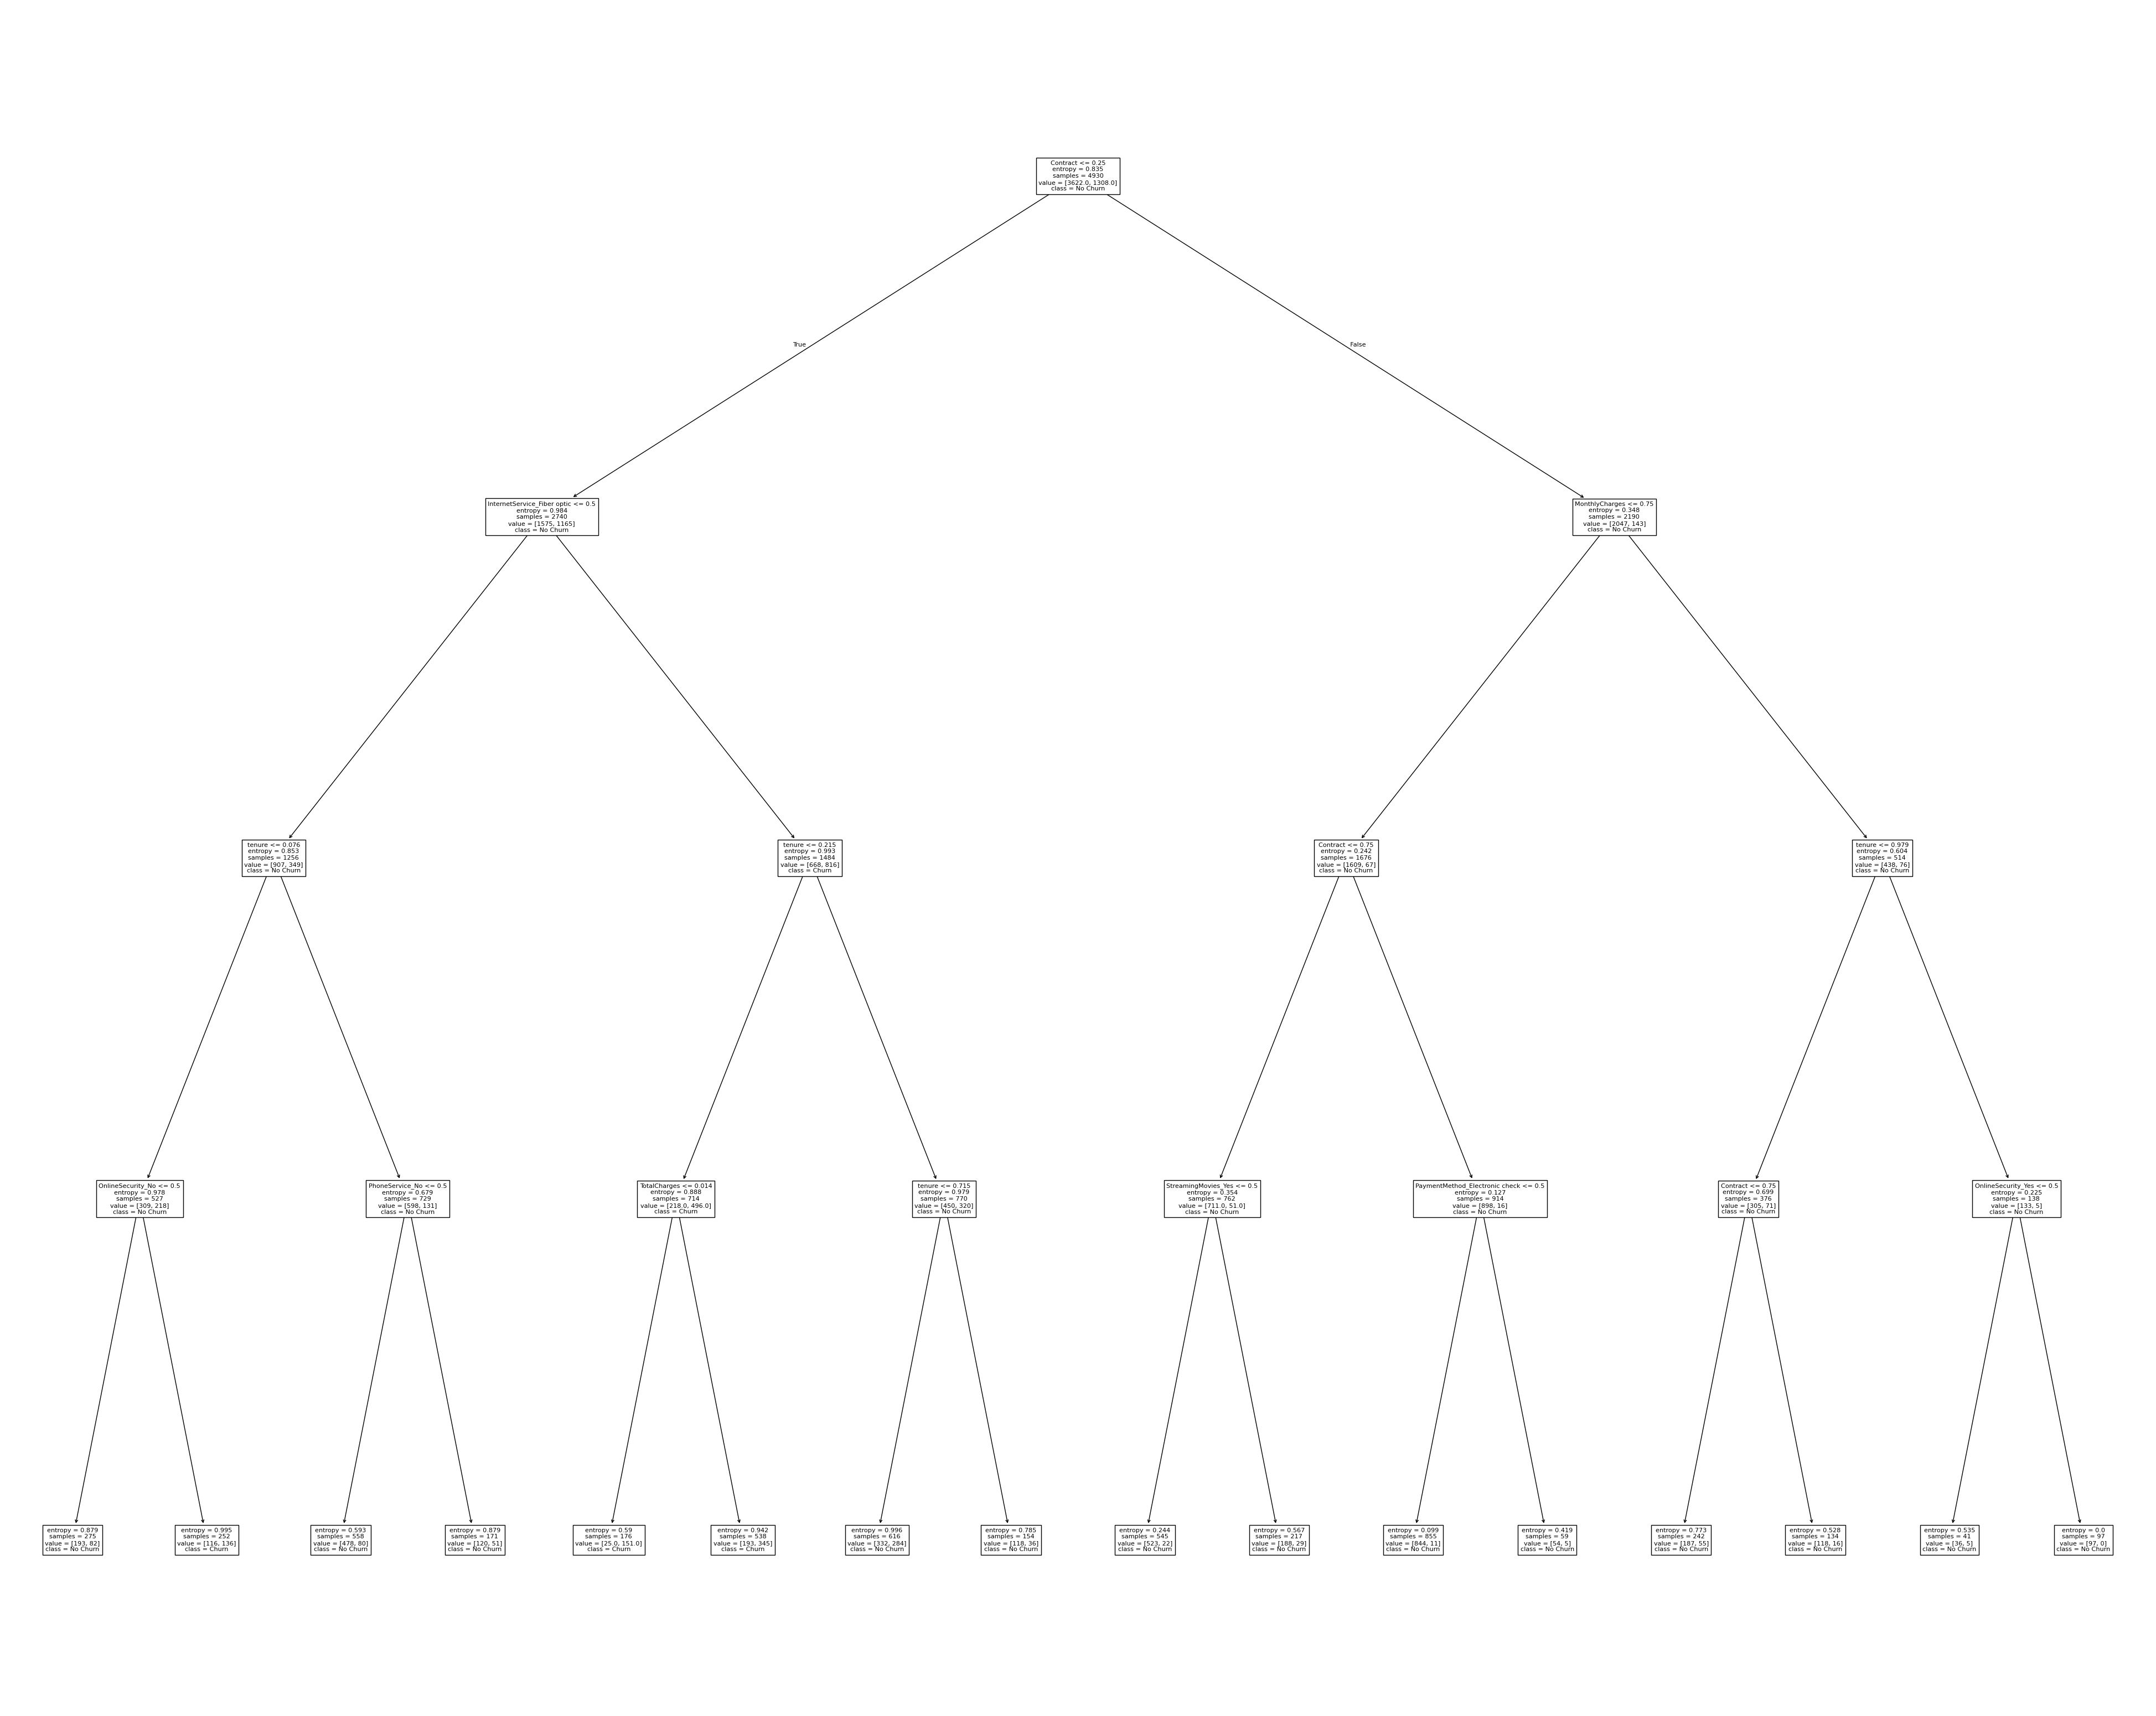

In [ ]:
#show the tree
plt.figure(figsize=(50,40))
tree.plot_tree(best_estimator_tree, feature_names=X.columns, class_names=['No Churn', 'Churn'])
plt.show()

### II. Perform the same tasks with the **balanced** training set. (10 pts)

In [ ]:
# Write your code here
#initialise
grid_decisionTree_balanced = GridSearchCV(DecisionTreeClassifier(criterion='entropy'),param_grid, scoring='roc_auc')

#train on the prev unbalanaced dataset
grid_decisionTree_balanced.fit(X_train, y_train)

GridSearchCV(estimator=DecisionTreeClassifier(criterion='entropy'),
             param_grid={'max_depth': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,
                                       14]},
             scoring='roc_auc')

In [ ]:
#save the best estimator
best_estimator_tree_balanced = grid_decisionTree_balanced.best_estimator_

#test it
y_pred_decisionTree_balanced = best_estimator_tree_balanced.predict(X_test)
y_proba_decisionTree_balanced = best_estimator_tree_balanced.predict_proba(X_test)
y_score_decisionTree_balanced = y_proba_decisionTree_balanced[:, 1]

In [ ]:
#display the results
print(confusion_matrix(y_test, y_pred_decisionTree_balanced))
print(classification_report(y_test, y_pred_decisionTree_balanced))

[[1216  336]
 [ 184  377]]
              precision    recall  f1-score   support

         0.0       0.87      0.78      0.82      1552
         1.0       0.53      0.67      0.59       561

    accuracy                           0.75      2113
   macro avg       0.70      0.73      0.71      2113
weighted avg       0.78      0.75      0.76      2113



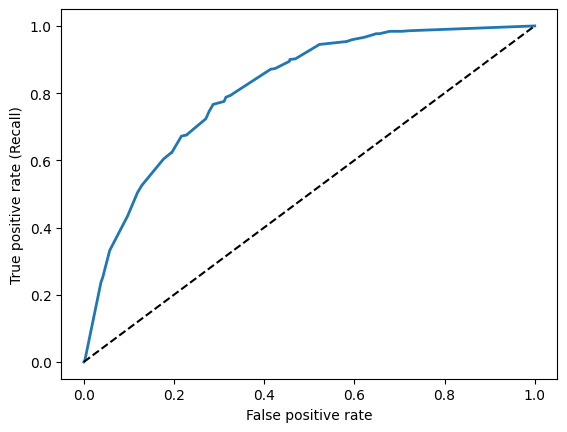

In [ ]:
#fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)
fpr, tpr, thresholds = roc_curve(y_test, y_score_decisionTree_balanced) #do it on the test set

#plot the curve

plot_roc_curve(fpr, tpr)

plt.xlabel("False positive rate")
plt.ylabel("True positive rate (Recall)")
plt.show()

In [ ]:
print("ROC AUC:", roc_auc_score(y_test, y_score_decisionTree_balanced))

ROC AUC: 0.812882463200838


In [ ]:
#misclassification
missclassified_decisionTree_balanced = (y_test != y_pred_decisionTree_balanced).sum()
print("Misclassifications: ", missclassified_decisionTree_balanced)

Misclassifications:  520


In [ ]:
#show the tree
plt.figure(figsize=(200,150))
tree.plot_tree(best_estimator_tree_balanced, feature_names=X.columns, class_names=['No Churn', 'Churn'])
plt.show()

### III. Short answer (markdown): Discuss the difference between the two trees, and discuss part of the tree from section I-II. (4 pts)

*Write your answer here.*

From the above tree diagrams, it's seen that both the trees split at "Contract" as this feature produces the largest drop in entropy. The unbalanced tree splits at Contract <= 0.25 while the balanced tree splits at <=0.499. We know the contract was ordinal encoded as month to month = 0, one year = 1, two year = 2 and then scaled to 0 and 1. Thus, 0 maps to 0.0, 1 maps to 0.5 and 2 maps to 1.0 in this case. Based on the mapping, customers with contract <= 0.499 for balanced tree with true goes one side of the branch while the ones with false follows the other side of the branch as per the image.

From the unbalanced tree the customers with month to month contract are further splitted into customers with internet service fibre optics of <= 0.5 and entropy 0.984. Here customers with no fiber optics follows one branch while customers without follows down the other branch. For balanced tree, at the same depth, customers are based on no Online security of <=0.007 with 0.904 entropy.

Unbalanced decision tree has a depth of 4 while balanced decision tree has a depth of 7.

The unbalanced tree predicts churn with precission of 0.64, recall 0.51 while balanced tree predicst churn with precision 0.53 and recall 0.67. The unbalanced here is more confident in predicting churns with a higher precision but the balanced tree predicts actual churners with more recall with the tradeoff of some false positives.



## J. Random Forest [15 pts = 8 + 1 + 6]

### I. Use grid search to tune `max_depth`, `min_samples_leaf`, and `n_estimators`. (helpful link:https://www.analyticsvidhya.com/blog/2021/06/understanding-random-forest/) [it may take few minutes (8 pts)

In [ ]:
# Write your code here
#import the libraries
from sklearn.ensemble import RandomForestClassifier

#classifier_rf = RandomForestClassifier(random_state=0, n_jobs=-1, max_depth=5, n_estimators=100, oob_score=True)

# %%time
# classifier_rf.fit(X_train, y_train)

#initialise
rf_params ={'max_depth': [3, 5, 10, 20],
            'min_samples_leaf': [5, 10, 20, 50],
            'n_estimators': [50, 100, 200]}

grid_rf = GridSearchCV(cv=4, estimator=RandomForestClassifier(n_jobs=-1, random_state=0), n_jobs=-1,
             param_grid = rf_params,
             scoring='roc_auc', verbose=1)

#train
grid_rf.fit(X_train, y_train)


Fitting 4 folds for each of 48 candidates, totalling 192 fits


GridSearchCV(cv=4, estimator=RandomForestClassifier(n_jobs=-1, random_state=0),
             n_jobs=-1,
             param_grid={'max_depth': [3, 5, 10, 20],
                         'min_samples_leaf': [5, 10, 20, 50],
                         'n_estimators': [50, 100, 200]},
             scoring='roc_auc', verbose=1)

### II. Print the best estimator. (1 pt)

In [ ]:
# Write your code here
print(grid_rf.best_estimator_)

RandomForestClassifier(max_depth=20, min_samples_leaf=5, n_estimators=200,
                       n_jobs=-1, random_state=0)


### III. Train the model, test it, print the confusion matrix and classification report, plot the ROC curve, show the AUC, and count the misclassifications. (6 pts)

In [ ]:
# Write your code here
#test
best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)
y_proba_rf = best_rf.predict_proba(X_test)
y_scores_rf = y_proba_rf[:, 1]

In [ ]:
#display the results
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

[[1282  270]
 [ 201  360]]
              precision    recall  f1-score   support

         0.0       0.86      0.83      0.84      1552
         1.0       0.57      0.64      0.60       561

    accuracy                           0.78      2113
   macro avg       0.72      0.73      0.72      2113
weighted avg       0.79      0.78      0.78      2113



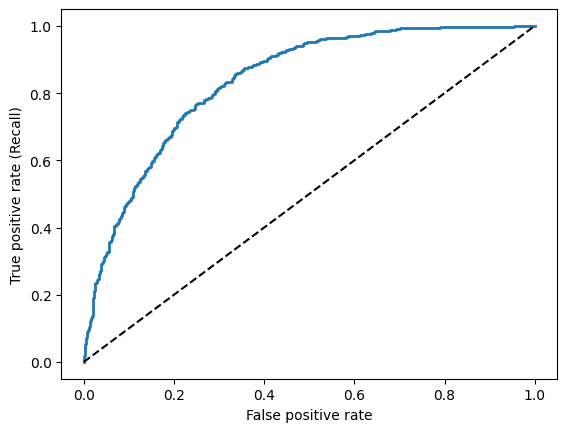

In [ ]:
#fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)
fpr, tpr, thresholds = roc_curve(y_test, y_scores_rf) #do it on the test set

#plot the curve

plot_roc_curve(fpr, tpr)

plt.xlabel("False positive rate")
plt.ylabel("True positive rate (Recall)")
plt.show()

In [ ]:
print("ROC AUC:", roc_auc_score(y_test, y_scores_rf))

ROC AUC: 0.8369833875443335


In [ ]:
#misclassification
missclassified_rf = (y_test != y_pred_rf).sum()
print("Misclassifications: ", missclassified_rf)

Misclassifications:  471


## K. Boosting Algorithms [10 pts = 5 + 5]

### I. Train an AdaBoostClassifier with manual or grid-search parameters. Test it, print the confusion matrix and classification report, plot the ROC curve, show the AUC, and count the misclassifications. (5 pts)

In [ ]:
# Write your code here
#import the library

from sklearn.ensemble import AdaBoostClassifier

#keeping some parameters consistent too
ada = AdaBoostClassifier(n_estimators=100, learning_rate=1, random_state=0)
ada.fit(X_train, y_train)

y_pred_ada = ada.predict(X_test)
y_proba_ada = ada.predict_proba(X_test)
y_scores_ada = y_proba_ada[:, 1]

In [ ]:
#display the results
print(confusion_matrix(y_test, y_pred_ada))
print(classification_report(y_test, y_pred_ada))

[[1205  347]
 [ 143  418]]
              precision    recall  f1-score   support

         0.0       0.89      0.78      0.83      1552
         1.0       0.55      0.75      0.63       561

    accuracy                           0.77      2113
   macro avg       0.72      0.76      0.73      2113
weighted avg       0.80      0.77      0.78      2113



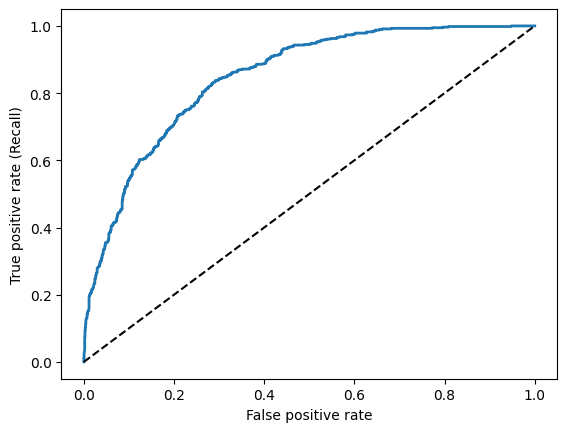

In [ ]:
#fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)
fpr, tpr, thresholds = roc_curve(y_test, y_scores_ada) #do it on the test set

#plot the curve

plot_roc_curve(fpr, tpr)

plt.xlabel("False positive rate")
plt.ylabel("True positive rate (Recall)")
plt.show()

In [ ]:
print("ROC AUC:", roc_auc_score(y_test, y_scores_ada))

ROC AUC: 0.8479720262050462


In [ ]:
#misclassification
missclassified_ada = (y_test != y_pred_ada).sum()
print("Misclassifications: ", missclassified_ada)

Misclassifications:  490


### II. Do the same for a GradientBoostingClassifier. (5 pts)
Helpful links:
https://www.analyticsvidhya.com/blog/2015/11/quick-introduction-boosting-algorithms-machine-learning/#:~:text=Types%20of%20Boosting%20Algorithms&text=AdaBoost%20(Adaptive%20Boosting),XGBoost

Another link: https://www.machinelearningplus.com/machine-learning/an-introduction-to-gradient-boosting-decision-trees/

In [ ]:
# Write your code here
#import the library

from sklearn.ensemble import GradientBoostingClassifier

#keeping some parameters consistent too
gdB = GradientBoostingClassifier(n_estimators=100, learning_rate=1, random_state=0)
gdB.fit(X_train, y_train)

y_pred_gdB = gdB.predict(X_test)
y_proba_gdB = gdB.predict_proba(X_test)
y_scores_gdB = y_proba_gdB[:, 1]

In [ ]:
#display the results
print(confusion_matrix(y_test, y_pred_gdB))
print(classification_report(y_test, y_pred_gdB))

[[1301  251]
 [ 259  302]]
              precision    recall  f1-score   support

         0.0       0.83      0.84      0.84      1552
         1.0       0.55      0.54      0.54       561

    accuracy                           0.76      2113
   macro avg       0.69      0.69      0.69      2113
weighted avg       0.76      0.76      0.76      2113



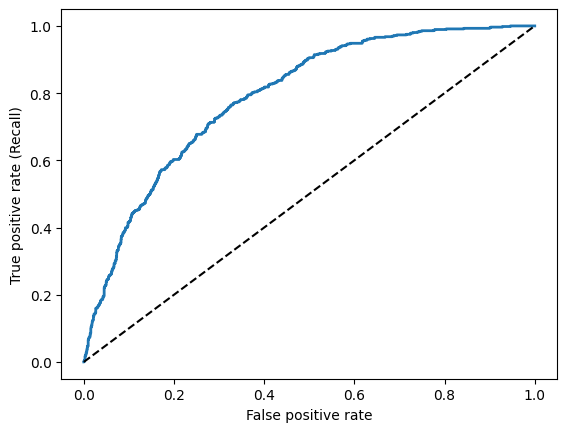

In [ ]:
#fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)
fpr, tpr, thresholds = roc_curve(y_test, y_scores_gdB) #do it on the test set

#plot the curve

plot_roc_curve(fpr, tpr)

plt.xlabel("False positive rate")
plt.ylabel("True positive rate (Recall)")
plt.show()

In [ ]:
print("ROC AUC:", roc_auc_score(y_test, y_scores_gdB))

ROC AUC: 0.7904716127313156


In [ ]:
#misclassification
missclassified_gdB = (y_test != y_pred_gdB).sum()
print("Misclassifications: ", missclassified_gdB)

Misclassifications:  510


## L. Final Discussion [10 pts]

### I. In a markdown cell, briefly discuss your findings, including which model is most suitable for this churn scenario and which metrics you based that on. Discuss performance on both the churn and non-churn classes and the effect of balanced versus unbalanced data. Then describe possible future work. (10 pts)

*Write your answer here.*

Here, the business idea is that we're predicting the customers who might churn. Thus, predicting false negatives (customers who are predicted to stay but actually left) is costly in this case. This is because losing a customer is a great loss for the company.

Here's the table of my finding so far for the customers who will Churn (1.0):

| model | precision | recall | AUC | Misclassification |
| --- | --- | --- | --- | --- |
| Logistic Regression with PCA | 0.52 | 0.79 | 0.845 | — |
| KNN with unbalanced set | 0.57 | 0.42 | — | — |
| KNN with balanced set | 0.47 | 0.73 | — | — |
| KNN unbalanced set with grid search | 0.47 | 0.58 | — | — |
| KNN balanced set with PCA | 0.43 | 0.59 | — | — |
| GaussianNB | 0.47 | 0.85 | 0.813 | 613 |
| categoricalNB | 0.46 | 0.86 | 0.807 | 642 |
| SVM | 0.56 | 0.41 | 0.722 | 513 |
| Decision Tree with unbalanced set | 0.64 | 0.51 | 0.836 | 435 |
| Decision Tree with balanced set | 0.53 | 0.67 | 0.813 | 520 |
| Random Forest | 0.57 | 0.64 | 0.837 | 471 |
| AdaBoosting | 0.55 | 0.75 | 0.848 | 490 |
| GradientBoosting | 0.55 | 0.54 | 0.790 | 510 |

<br>

Based on the table, the worst model is SVM with a recall of 0.41 while categoricalNB has recall of 0.86 but low precision of 0.46. AdaBoosting has the best balanced score of recall 0.75 with good precision 0.55 among other models. Here we're focussing on recall as we're more concerned of false negatives.

The unbalanced dataset leads misleading recall values as seen in KNN and Decision Tree with unbalaced dataset of 0.42 and 0.51 respectively. This is because majority of the customers are "No churn" according to the dataset. Thus, many customers are marked as false negatives.

Here's the table of my finding so far for the customers who will not Churn (0.0):

| model | precision | recall | AUC | Misclassification |
| --- | --- | --- | --- | --- |
| Logistic Regression with PCA | 0.52 | 0.79 | 0.845 | — |
| KNN with unbalanced set | 0.81 | 0.88 | — | — |
| KNN with balanced set | 0.88 | 0.71 | — | — |
| KNN unbalanced set with grid search | 0.83 | 0.76 | — | — |
| KNN balanced set with PCA | 0.83 | 0.72 | — | — |
| GaussianNB | 0.92 | 0.66 | 0.813 | 613 |
| categoricalNB | 0.93 | 0.64 | 0.807 | 642 |
| SVM | 0.81 | 0.88 | 0.722 | 513 |
| Decision Tree with unbalanced set | 0.84 | 0.90 | 0.836 | 435 |
| Decision Tree with balanced set | 0.87 | 0.78 | 0.813 | 520 |
| Random Forest | 0.86 | 0.83 | 0.837 | 471 |
| AdaBoosting | 0.89 | 0.78 | 0.848 | 490 |
| GradientBoosting | 0.89 | 0.84 | 0.790 | 510 |

<br>

In the above table, majority of the models predicted non churning customers great with precision of >= 0.80. The best model with great precision of 0.89 and recall 0.84 is Gradient boosting

Again the unbalanced dataset leads misleading recall values as seen in KNN and Decision Tree with unbalaced dataset of 0.88 and 0.90 respectively. This is because majority of the customers are "No churn" as said earlier.

In the future, one of the things we need to do is we need to adress the class imbalance using SMOTE technique to generete synthetic data to balance the classes. We can assign a cost matrix to multiply with the confusion matrix to calculate the cost. In addition, we need to identify which features are the main driver factors in terms of "Churn".